In [ ]:
""" 
Author: Weronika Golletz

Updates:
2 Mar 2026: create notebook, plan it structure
3-4 Mar 2026: filling sections content
"""

' \nAuthor: Weronika Golletz\n\nUpdates:\n2 Mar 2026: create notebook, plan it structure\n'

In [2]:
import sys
import os

# This adds the parent directory to the search path
sys.path.append(os.path.abspath(".."))


%load_ext autoreload
%autoreload 2
from src.mltoolbox import *

# import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix,classification_report
import seaborn as sns
import matplotlib.pyplot as plt 


# Motivation

# Generate Synthetic Dataset

Let's generate a synthetic dataset to understand how metrics behave under different conditions:
1. Balanced dataset
2. Imbalanced dataset
3. ...

We assume the true labels are generated from a categorical distribution:
$$ y_{\text{true}} \sim \text{Categorical}(\pi)$$
where $\pi = (\pi_1,\dots,\pi_K)$, $\pi_k=P(Y=k)$, and $\sum_k \pi_k = 1$. This vector $\pi$ defines the class distribution.

It controls whether the dataset is:
- Balanced (all classes equally likely)
- Imbalanced (some classes rare).

We simulate, the classifier's behavior in the following way. First, define a matrix $P \in \mathbb{R}^{K\times K}$:
$$y_{\text{pred}} | y_{\text{true}} = k \sim \text{Categorical(P[k,:])}$$
The matrix encodes:
$$P_{k,j} = P(\hat{Y}=j | Y=k)$$

Thus, each row corresponds to: if the true class is $k$, how does the model distribute its predictions?

Each row of matrix $P$ must sum to $1$:
$$ \sum_j P_{k,j}=1 $$
The diagonal entries are the probabilities of correct predition, i.e. model accuracy for class $k$. The off-diagonal entries are probabilities of confusing class $k$ with class $j$. 

The matrix $P$ is sometimes called:
- transition matrix,
- noise matrix,
- conditional confusion matrix.
With this matrix we actively design the error structure.

We will create three cases of datasets:
1. **Balanced Dataset:** $$\pi = [\frac{1}{K},\dots,\frac{1}{K}]$$ Thus every class appears equally often. This dataset is used for understanding pure precision/recall trade-offs and to demonstrate the baselines.
2. **Imbalanced Dataset:** $$ \pi = [0.8,0.15,0.05]$$ Thus the class 0 dominate, class 2 is rare. This allows us to observe why accuracy can be misleading, why macro vs weighted metrics differ, and how minority recall behaves. Here, imbalance comes from the data, not the model.
3. **Structured Confusion:** </br>
 matrix $P$ is encoded for a specific failare pattern. Here, class 2 is often mistaken for class 1, i.e. $P_{2,1}$ is large. Thanks this example, we simulate realistic structure of similar-looking classes, semantic overlap and hard-to-distinguish categories. This helps us to observe: class-specific precision collapse, asymmetric confusion and impact on macro-F1.

In [11]:
# --- Balanced Case ---
print(f" ### BALANCED CASE ### ")
K = 3
N = 2000

pi_balanced = make_class_probs(K, kind="balanced")
P_generic = make_transition_matrix(K, diag_acc=0.75)

y_true_A, y_pred_A = simulate_labels(N, K, pi_balanced, P_generic, seed=0)

print("pi_balanced:", pi_balanced)
# print("P_generic:\n", P_generic)
print("Expected accuracy:", expected_accuracy(pi_balanced, P_generic))

# --- Imbalanced Case ---
print(f"\n ### IMBALANCED CASE ### ")
pi_imbalanced = make_class_probs(K, kind="imbalanced", imbalance=[0.80, 0.15, 0.05])

y_true_B, y_pred_B = simulate_labels(N, K, pi_imbalanced, P_generic, seed=0)

print("pi_imbalanced:", pi_imbalanced)
print("Expected accuracy:", expected_accuracy(pi_imbalanced, P_generic))

# # --- Structures Confusion ---
# print(f" ### STRUCTURE CONFUSION ### ")
# # class 2 often mistaken for class 1
# structure = {
#     (2, 1): 0.20  # true=2 -> pred=1 with prob 0.20
# }

# P_structured = make_transition_matrix(K, diag_acc=0.75, structure=structure)
# y_true_C, y_pred_C = simulate_labels(N, K, pi_balanced, P_structured, seed=0)

# print("P_structured:\n", P_structured)
# print("Expected accuracy:", expected_accuracy(pi_balanced, P_structured))

# print("\n#########\nSanity Check")
# print("Empirical acc A:", empirical_accuracy(y_true_A, y_pred_A))
# print("Empirical acc B:", empirical_accuracy(y_true_B, y_pred_B))
# print("Empirical acc C:", empirical_accuracy(y_true_C, y_pred_C))

 ### BALANCED CASE ### 
Class 0: 671 samples (33.6%)
Class 1: 655 samples (32.8%)
Class 2: 674 samples (33.7%)
pi_balanced: [0.33333333 0.33333333 0.33333333]
Expected accuracy: 0.75

 ### IMBALANCED CASE ### 
Class 0: 1588 samples (79.4%)
Class 1: 312 samples (15.6%)
Class 2: 100 samples (5.0%)
pi_imbalanced: [0.8  0.15 0.05]
Expected accuracy: 0.7500000000000001


# Build Confusion Matrix

Now, we are going from synthetic dataset to confusion matrix. So far, we generated:
- $y_{\text{true}}$ from the class distribution $\pi$
- $y_{\text{pred}}$ from the transition matrix $P$.

The confusion matrix is the empirical estimate of the joint distribution $P(\hat{Y},Y)$. scaled by sample size.



In [13]:
cm_A = get_confusion_matrix(y_true_A, y_pred_A)
cm_B = get_confusion_matrix(y_true_B, y_pred_B)
cm_A, cm_B

(array([[512,  86,  73],
        [ 79, 504,  72],
        [ 73, 102, 499]]),
 array([[1197,  211,  180],
        [  33,  243,   36],
        [  11,   20,   69]]))

The confusion matrix structure:
1. Row $i$ contains all samples whose true class is $i$, i.e. each row shows how the model distributes predictions for that true class.
2. Column $j$ contains all samples predited as class $j$, i.e. each column shows the 'purity' of predictions for that class.
3. Diagonal entries are the correctly classified samples. The sum over diagonal gives the model accuracy, i.e. the number of correct predictions $\frac{\text{Diagonal Sum}}{\text{Total Samples}}$.

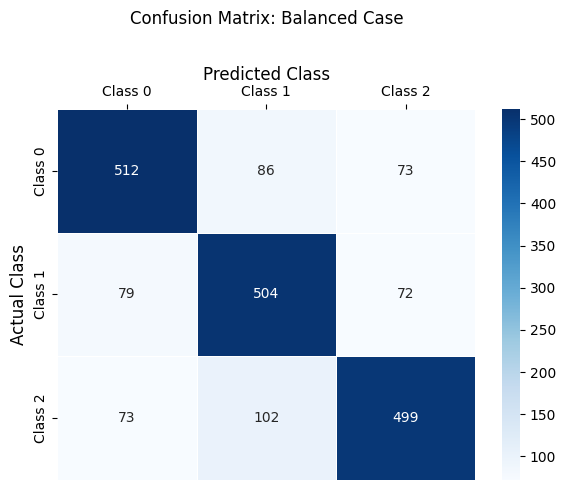

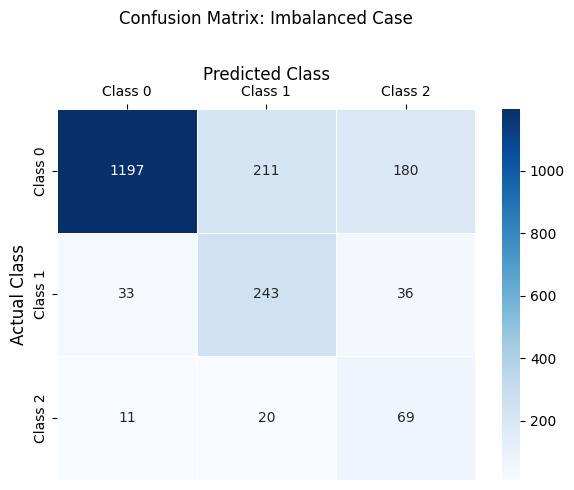

In [14]:
import seaborn as sns
import matplotlib.pyplot as plt

plot_confusion_matrix(cm_A, data_type = "Balanced Case")
plot_confusion_matrix(cm_B, data_type = "Imbalanced Case")

# One-vs-Rest Decomposition

In multiclass classification we can evaluate each class as if it were a binary problem:
- "positive" = this class $k$
- "negative" = all other classes $\neq k$

This is called one-vs-rest.

For a confusion matrix $CM \in \mathbb{R}^{K\times K}$ (rows=actual, columns = predicted), define for each class $k$:
- $TP_k = CM_{k,k}$ (True Positives)
- $FN_k = \sum_{j \neq k} CM_{k,j}$ (missed class $k$: actual $k$ predicted as not-$k$; False Negative)
- $FP_k = \sum_{i \neq k} CM_{i, k}$ (false alarms: predicted $k$ but actual not-$k$; False Positive)
- $TN_k = N - (TP_k + FP_k + FN_K)$ (True Negatives), $N=\sum_{i,j} CM_{i,j}$ is the total number of samples.



In [15]:
ovr_df_A = get_TP_FP_FN_TN(cm_A)
ovr_df_B = get_TP_FP_FN_TN(cm_B)
ovr_df_A, ovr_df_B

(   class   TP   FP   FN    TN  support (actual count)
 0      0  512  152  159  1177                     671
 1      1  504  188  151  1157                     655
 2      2  499  145  175  1181                     674,
    class    TP   FP   FN    TN  support (actual count)
 0      0  1197   44  391   368                    1588
 1      1   243  231   69  1457                     312
 2      2    69  216   31  1684                     100)

# Precision

Precision = “column purity” (trust when the model predicts class $k$)

For class $k$, precision answers: Among everything predicted as class $k$, how much was truly class $k$?
$$\text{Precision}_k = \frac{TP_k}{TP_k + FP_k} $$

This is a conditional probability:
$$\text{Precision}_k = P(Y=k | \hat{Y} =k )$$

So precision is about how reliable the prediction “k” is.


Precision matters when false positives are costly, e.g.:
- Spam filter: don’t mark important emails as spam
- Fraud detection: don’t freeze legitimate customers
- Medical treatment: don’t treat healthy patients unnecessarily

High precision means:
- when the model predicts class $k$, it’s usually correct.

Low precision means:
- lots of “false alarms” for class $k$

In [19]:
def safe_div(a, b):
    return a / b if b != 0 else np.nan

print(f" ### BALANCED CASE ### ")
ovr_df2 = ovr_df_A.copy()
ovr_df2["precision"] = [
    safe_div(row.TP, row.TP + row.FP) for row in ovr_df2.itertuples(index=False)
]
print(ovr_df2[["class", "TP", "FP", "precision"]])

print(f"\n ### IMBALANCED CASE ### ")
ovr_df2 = ovr_df_B.copy()
ovr_df2["precision"] = [
    safe_div(row.TP, row.TP + row.FP) for row in ovr_df2.itertuples(index=False)
]
ovr_df2[["class", "TP", "FP", "precision"]]

 ### BALANCED CASE ### 
   class   TP   FP  precision
0      0  512  152   0.771084
1      1  504  188   0.728324
2      2  499  145   0.774845

 ### IMBALANCED CASE ### 


,class,TP,FP,precision
0,0,1197,44,0.964545
1,1,243,231,0.512658
2,2,69,216,0.242105


# Recall

Recall = “row coverage” (how much of the true class did we catch?)

For class $k$, recall answers: Among all samples that truly belong to class 
$k$, how many did we correctly predict as $k$?
$$\text{Recall}_k = \frac{TP_k}{TP_k + FN_k}$$

This is a conditional probability:
$$\text{Recall}_k = P(\hat{Y}=k | Y = k)$$

So recall measures how well we cover the true class.
- High recall == few missed positives (few FN)
- Low recall == many true class $k$ samples are predicted as other classes

The term $FN_k$ counts missed positives:
- They are truly class $k$
- But the model predicted “not $k$”

Sensitivity interpretation
- In many fields recall is also called sensitivity (especially in medicine):
    - High sensitivity means you catch most true cases.
    - Low sensitivity means you miss many true cases.
- Example: Disease screening: high recall is critical (missing a sick patient is costly).

In [22]:
def recall_from_counts(TP, FN):
    return TP / (TP + FN) if (TP + FN) != 0 else np.nan

print(f" ### BALANCED CASE ### ")
ovr_df_A["recall"] = [recall_from_counts(r.TP, r.FN) for r in ovr_df_A.itertuples(index=False)]
print(ovr_df_A[["class", "TP", "FN", "recall"]])

print(f"\n ### IMBALANCED CASE ### ")
ovr_df_B["recall"] = [recall_from_counts(r.TP, r.FN) for r in ovr_df_B.itertuples(index=False)]
ovr_df_B[["class", "TP", "FN", "recall"]]

 ### BALANCED CASE ### 
   class   TP   FN    recall
0      0  512  159  0.763040
1      1  504  151  0.769466
2      2  499  175  0.740356

 ### IMBALANCED CASE ### 


,class,TP,FN,recall
0,0,1197,391,0.753778
1,1,243,69,0.778846
2,2,69,31,0.690000


# Precision-Recal Tradeoff

For threshold tradeoff, the cleanest demo is binary classification (because thresholds apply naturally to a “score/probability for positive class”).

Many models output a score $s(x)$ (e.g., predicted probability of the positive class).

To convert scores into hard labels, we choose a threshold $t$:
- Predict positive if $s(x) >= t$
- Predict negative otherwise

As we increase the threshold:
- We become more conservative about predicting positive
- False positives usually decrease ⇒ precision increases
- True positives may also decrease ⇒ recall decreases

So typically: threshold increase ⇒ precision increase and recall decrease

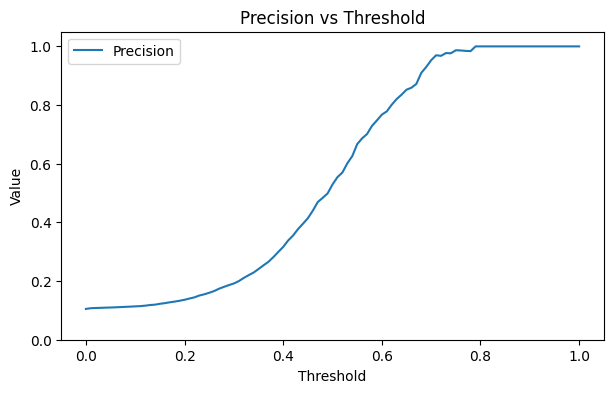

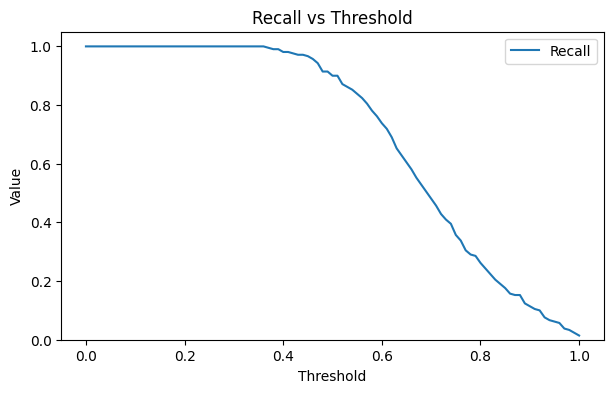

In [14]:
import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng(0)
N = 2000

# Create an imbalanced binary problem (10% positives)
y_true = (rng.random(N) < 0.10).astype(int)

# Simulate model scores:
# positives tend to have higher scores, negatives lower, but overlap exists
scores = np.empty(N)
scores[y_true == 1] = rng.normal(loc=0.70, scale=0.15, size=(y_true == 1).sum())
scores[y_true == 0] = rng.normal(loc=0.30, scale=0.15, size=(y_true == 0).sum())

# clamp to [0,1]
scores = np.clip(scores, 0, 1)

def precision_recall_at_threshold(y_true, scores, thr):
    y_pred = (scores >= thr).astype(int)

    TP = np.sum((y_true == 1) & (y_pred == 1))
    FP = np.sum((y_true == 0) & (y_pred == 1))
    FN = np.sum((y_true == 1) & (y_pred == 0))

    precision = TP / (TP + FP) if (TP + FP) else np.nan
    recall = TP / (TP + FN) if (TP + FN) else np.nan
    return precision, recall

thresholds = np.linspace(0, 1, 101)
precisions = []
recalls = []

for thr in thresholds:
    p, r = precision_recall_at_threshold(y_true, scores, thr)
    precisions.append(p)
    recalls.append(r)

precisions = np.array(precisions, dtype=float)
recalls = np.array(recalls, dtype=float)

plt.figure(figsize=(7,4))
plt.plot(thresholds, precisions, label="Precision")
plt.xlabel("Threshold")
plt.ylabel("Value")
plt.title("Precision vs Threshold")
plt.ylim(0, 1.05)
plt.legend()
plt.show()

plt.figure(figsize=(7,4))
plt.plot(thresholds, recalls, label="Recall")
plt.xlabel("Threshold")
plt.ylabel("Value")
plt.title("Recall vs Threshold")
plt.ylim(0, 1.05)
plt.legend()
plt.show()

# F1 Score

Why Harmonic Mean?

F1 balances precision and recall:
$$ F1 = 2 \frac{PR}{P+R} $$

It uses the harmonic mean, not the arithmetic mean, because it punishes imbalance.

If one of precision/recall is very low, F1 will also be low.

F1 says: you only get a high score if you are good at BOTH: not creating false alarms (precision) and not missing positives (recall).

In [15]:
P = 1.0
R = 0.1

arith = (P + R) / 2
f1 = 2 * P * R / (P + R)

print("Precision:", P)
print("Recall:", R)
print("Arithmetic mean:", arith)
print("F1:", f1)

Precision: 1.0
Recall: 0.1
Arithmetic mean: 0.55
F1: 0.18181818181818182


# Accuracy

Accuracy is:
$$\text{Accuracy} = \frac{\text{num. correct}}{\text{total num}}$$

In imbalanced datasets, accuracy can look high even if the model is useless.

Example:
- 95% of samples are class 0
- A “dumb” model predicts class 0 for everything
- Then:
    - Accuracy = 95% (looks great)
    - But recall for minority class 1 = 0 (we never detect it)

This is why accuracy alone is not enough under imbalance.

In [16]:
import numpy as np

N = 2000
rng = np.random.default_rng(0)

# 95% class 0, 5% class 1
y_true = (rng.random(N) < 0.05).astype(int)  # 1 with prob 0.05
y_pred = np.zeros(N, dtype=int)              # always predict 0

# confusion counts
TP = np.sum((y_true == 1) & (y_pred == 1))
FP = np.sum((y_true == 0) & (y_pred == 1))
FN = np.sum((y_true == 1) & (y_pred == 0))
TN = np.sum((y_true == 0) & (y_pred == 0))

accuracy = (TP + TN) / N
precision = TP / (TP + FP) if (TP + FP) else np.nan
recall = TP / (TP + FN) if (TP + FN) else 0.0
f1 = 2 * precision * recall / (precision + recall) if (precision + recall) else 0.0

print("Counts: TP, FP, FN, TN =", TP, FP, FN, TN)
print("Accuracy:", accuracy)
print("Recall (minority class=1):", recall)
print("F1 (minority class=1):", f1)

Counts: TP, FP, FN, TN = 0 0 110 1890
Accuracy: 0.945
Recall (minority class=1): 0.0
F1 (minority class=1): nan


# Macro vs Micro vs Weighted

When classes are imbalanced, how we average per-class metrics matters.

Assume we already computed per-class:
- Precision_k
- Recall_k
- F1_k
- Support_k = number of true samples of class k

We now define three averaging strategies.

1. Macro Average </br>
$$\text{Macro} = \frac{1}{K}\sum_{k=1}^K \text{metric}_k$$
All classes contribute equally, regardless of size.
- Treats minority classes fairly
- Good when each class is equally important

2. Weighted Average </br>
$$\text{Weighted} = \sum_{k=1}^K w_k \cdot \text{metric_k}$$
where
$$w_k = \frac{\text{support}_k}{N}$$
All classes contribute equally, regardless of size.
- Treats minority classes fairly
- Good when each class is equally important

3. Micro Average </br>
Compute global TP, FP, FN across all classes first
$$\text{Micro Precision} = \frac{\sum_k TP_k}{\sum_k (TP_k + FP_k)}$$
In single-label multiclasee:
$$\text{Micro precision}  = \text{Micro Recall} = \text{Accuracy}$$
- Counts global decisions
- Good for overall performance

In [17]:
import numpy as np
import pandas as pd

# Create imbalanced confusion matrix manually
cm_imb = np.array([
    [950,  30,  20],
    [ 40,  40,  20],
    [ 10,  25,  15]
])

def per_class_metrics(cm):
    K = cm.shape[0]
    N = cm.sum()
    rows = []
    for k in range(K):
        TP = cm[k,k]
        FN = cm[k,:].sum() - TP
        FP = cm[:,k].sum() - TP
        precision = TP/(TP+FP) if TP+FP else np.nan
        recall = TP/(TP+FN) if TP+FN else np.nan
        f1 = 2*precision*recall/(precision+recall) if precision+recall else np.nan
        support = cm[k,:].sum()
        rows.append([k, precision, recall, f1, support])
    return pd.DataFrame(rows, columns=["class","precision","recall","f1","support"])

df = per_class_metrics(cm_imb)
df

,class,precision,recall,f1,support
0,0,0.950000,0.95,0.950000,1000
1,1,0.421053,0.40,0.410256,100
2,2,0.272727,0.30,0.285714,50


In [18]:
N = cm_imb.sum()

macro_f1 = df["f1"].mean()

weighted_f1 = np.sum(df["f1"] * df["support"]) / N

# Micro (single-label case = accuracy)
accuracy = np.trace(cm_imb) / N
micro_f1 = accuracy

print("Macro F1:", macro_f1)
print("Weighted F1:", weighted_f1)
print("Micro F1 (accuracy):", micro_f1)

Macro F1: 0.5486568986568986
Weighted F1: 0.8741837872272656
Micro F1 (accuracy): 0.8739130434782608


When to use each?

Macro - trat classes equally - minority classes matter

Weighted - do not treat classes equally - reflect real-world distribution

Micro - global decisions - overal system performence

# Probabilistic Interpretation

The confusion matrix is an empirical estimate of:
$$P(\hat{Y},Y)$$
The confusion matrix is an empirical estimate of:
$$\hat{P}(\hat{Y}=j,Y=i)$$

From this joint distribution:
$$\text{Precision}_k = P(Y=k | \hat{Y}=k)$$
This looks at a column.

$$\text{Recall}_k = P(\hat{Y}=k | Y=k)$$
This looks at a row.

They are reverse conditional probabilities:
- Precision conditions on predictions.
- Recall conditions on truth.

This is why they behave differently.

# Cost-Sensitive Perspective

# Modern Extensions

1. ROC-AUC
    - Measures ranking quality across all thresholds.
    - Derived from varying confusion matrix over thresholds.

2. PR-AUC
    - Better under imbalance.
    - Area under precision–recall curve.

3. mAP (Object Detection)
    - Mean of precision across recall levels.
    - Built from precision–recall curves.

4. Calibration Metrics
    - Brier Score
    - Expected Calibration Error (ECE)
    - Measure whether predicted probabilities match reality.
    - Confusion matrix only uses hard labels; calibration uses probabilities.

# Ready-to-Use Libraries

# Summary

1. Core Ideas
    - The confusion matrix is the fundamental object.
    - Metrics are different projections of it.
    - Precision = column purity.
    - Recall = row coverage.
    - F1 penalizes imbalance between precision and recall.
    - Accuracy ignores class imbalance.
    - Macro, weighted, and micro differ in how they aggregate.

2. Deep Insight
    - Metrics reflect assumptions about error costs.
    - Choosing a metric is choosing what type of error you care about.